# Notebook 01: Exploratory Data Analysis & Data Governance

**Objective:** Before any modeling, we must establish strict data governance. This notebook verifies the cryptographic integrity of the dataset, explores missingness, and identifies extreme outliers. Furthermore, we explicitly define our leakage control strategy.

**Leakage Exclusions Justified:**
To prevent information leakage, outcome and post-event variables must not be used as clustering inputs. We explicitly exclude:
* `is_canceled` and `reservation_status`: These are the target/outcome variables.
* `reservation_status_date`: Realized post-booking.
* `adr` (Average Daily Rate): Retained only for post-hoc profiling.

In [ ]:
import pandas as pd
import numpy as np
import hashlib
import os
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## 1.1 Dataset Integrity Verification
We verify that our local dataset matches the `course release v1` exactly using the provided SHA-256 hash.

In [32]:
RAW_DATA_PATH = '../data/raw/hotel_bookings_course_release_v1.csv'
HASH_FILE_PATH = '../data/SHA256SUMS.txt'

def verify_dataset_hash(csv_path, hash_path):
    if not os.path.exists(csv_path):
        return "Dataset not found. Please ensure it is placed in the data/raw/ folder."
    if not os.path.exists(hash_path):
        return "Hash file not found. Please ensure SHA256SUMS.txt is in the data/ folder."
    
    sha256_hash = hashlib.sha256()
    with open(csv_path, "rb") as f:
        for byte_block in iter(lambda: f.read(4096), b""):
            sha256_hash.update(byte_block)
    calculated_hash = sha256_hash.hexdigest()
    
    with open(hash_path, "r") as f:
        expected_hash_line = f.readline().strip()
        expected_hash = expected_hash_line.split()[0]
        
    print(f"Calculated Hash: {calculated_hash}")
    print(f"Expected Hash:   {expected_hash}\n")
    
    if calculated_hash == expected_hash:
        return "- Integrity Check Passed: The dataset matches the course release exactly."
    else:
        return "- Integrity Check Failed: The hashes do not match."

print(verify_dataset_hash(RAW_DATA_PATH, HASH_FILE_PATH))

Calculated Hash: 7c2ae42a7353905ea136e5c2287f17c92c5435826598bfbb8491c6f0c7b1fc06
Expected Hash:   7c2ae42a7353905ea136e5c2287f17c92c5435826598bfbb8491c6f0c7b1fc06

- Integrity Check Passed: The dataset matches the course release exactly.


## 1.2 Missing Data & Outlier Summary

In [33]:
df = pd.read_csv(RAW_DATA_PATH)

print(f"Dataset Shape: {df.shape[0]:,} rows (bookings) and {df.shape[1]} columns (features)")
display(df.head(3))

Dataset Shape: 119,390 rows (bookings) and 32 columns (features)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


In [34]:
cat_cols = df.select_dtypes(exclude=[np.number]).columns

cat_missing = df[cat_cols].isnull().sum()
cat_missing_pct = (cat_missing / len(df)) * 100

cat_missing_df = pd.DataFrame({
    'Missing Values': cat_missing,
    'Percentage (%)': cat_missing_pct
}).sort_values(by='Percentage (%)', ascending=False)

print("Missingness Summary:")

display(cat_missing_df[cat_missing_df['Missing Values'] > 0])

Missingness Summary:


,Missing Values,Percentage (%)
country,488,0.408744


In [35]:
core_num_vars = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 
    'adults', 'children', 'babies', 'previous_cancellations', 
    'previous_bookings_not_canceled', 'adr'
]

print("Outlier & Heavy Tail Summary:")
display(df[core_num_vars].describe().round(2))

print("\nSpecific Anomaly Checks:")
print(f"Bookings with ADR < 0: {(df['adr'] < 0).sum()} (Data Error)")
print(f"Bookings with ADR > 1000: {(df['adr'] > 1000).sum()} (Extreme Outlier)")
print(f"Bookings with 0 adults: {(df['adults'] == 0).sum()} (Edge Case)")

Outlier & Heavy Tail Summary:


,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,adr
count,119390.00,119390.00,119390.00,119390.00,119386.0,119390.00,119390.00,119390.00,119390.00
mean,104.01,0.93,2.50,1.86,0.1,0.01,0.09,0.14,101.83
std,106.86,1.00,1.91,0.58,0.4,0.10,0.84,1.50,50.54
min,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,-6.38
25%,18.00,0.00,1.00,2.00,0.0,0.00,0.00,0.00,69.29
50%,69.00,1.00,2.00,2.00,0.0,0.00,0.00,0.00,94.58
75%,160.00,2.00,3.00,2.00,0.0,0.00,0.00,0.00,126.00
max,737.00,19.00,50.00,55.00,10.0,10.00,26.00,72.00,5400.00



Specific Anomaly Checks:
Bookings with ADR < 0: 1 (Data Error)
Bookings with ADR > 1000: 1 (Extreme Outlier)
Bookings with 0 adults: 403 (Edge Case)


## 1.3 Correlation Analysis
Before clustering, it is crucial to understand the linear relationships between our continuous variables. High multicollinearity can disproportionately weight certain dimensions in Euclidean space. We compute the Pearson correlation matrix for our core numerical features.

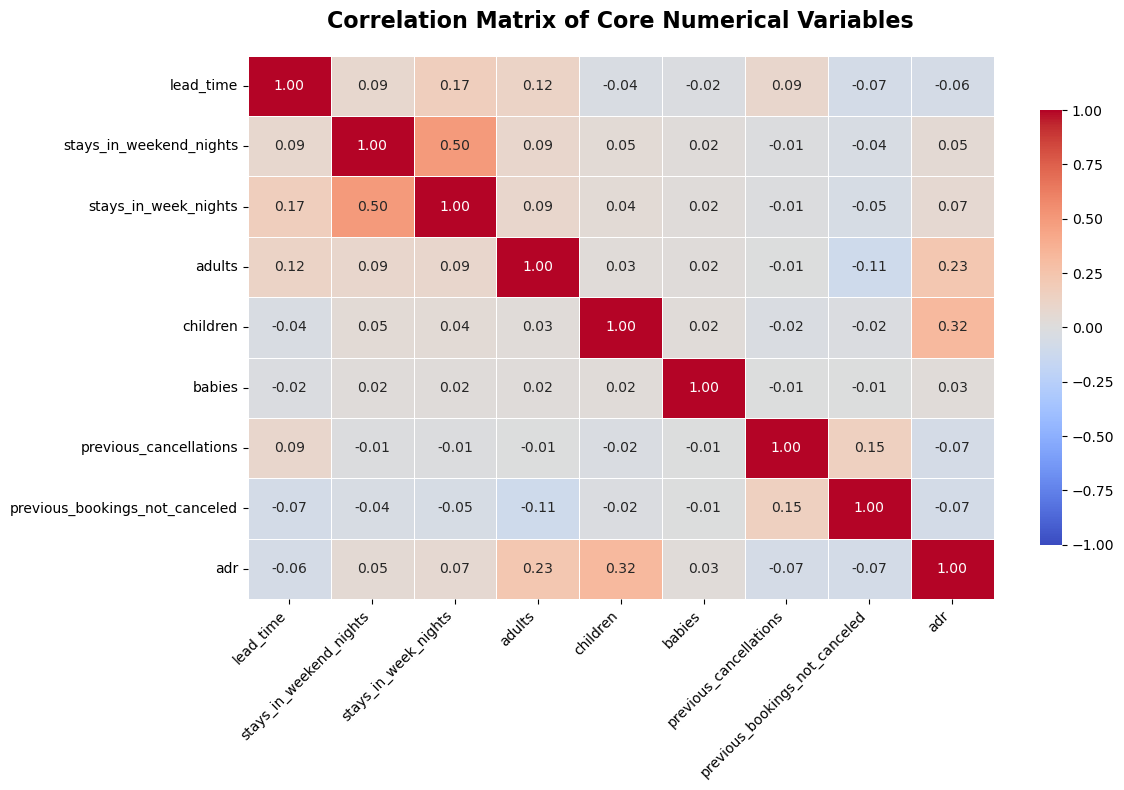

In [ ]:
corr_matrix = df[core_num_vars].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix, 
    annot=True,         
    fmt=".2f",          
    cmap="coolwarm", 
    vmin=-1, vmax=1,     
    linewidths=0.5, 
    cbar_kws={"shrink": .8}
)

plt.title("Correlation Matrix of Core Numerical Variables", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

os.makedirs('../figures', exist_ok=True)
plt.savefig("../figures/eda_correlation_matrix.png", dpi=150)

plt.show()

**EDA Conclusions for Preprocessing:**
1. **Missing Data:** Only `children` has minimal missing values (4 instances), which will be imputed with 0.
2. **Skewness:** Variables like `lead_time` exhibit severe right-skewness (max 737 days), requiring a `log1p` transformation.
3. **Outliers:** The presence of extreme outliers mandates a robustness check using `RobustScaler` in our modeling phase.